# Bicycle Rental Demand Prediction Project

## Introduction

This Jupyter Notebook demonstrates a data science project focused on predicting daily bicycle rental demand. We will utilize a dataset containing historical bicycle rental information along with various features such as weather conditions, day of the week, and seasonal information. The project follows a typical data science workflow, including data loading, exploration, feature engineering, model building, and evaluation. Our primary goal is to build a linear regression model that can accurately predict the number of bicycle rentals on a given day.

We will start by loading and inspecting the dataset, followed by exploratory data analysis to understand the relationships between different features and the rental demand. We will then proceed to feature engineering to potentially create new, more informative features. Finally, we will train a linear regression model and evaluate its performance on a separate validation dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = [10, 5]

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("day.csv")
df['date'] = pd.to_datetime(df['dteday'])
df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,date
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,2011-01-01
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,2011-01-02
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,2011-01-03
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2011-01-04
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2011-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114,2012-12-27
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095,2012-12-28
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341,2012-12-29
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796,2012-12-30


## 2. Exploratory Data Analysis (EDA)

In this section, we will explore the dataset to gain insights into the patterns and relationships within the data. We will visualize the rental counts over time and investigate the impact of weather conditions on bicycle demand.


## 2.1 Rental Count Over Time with Weather Conditions


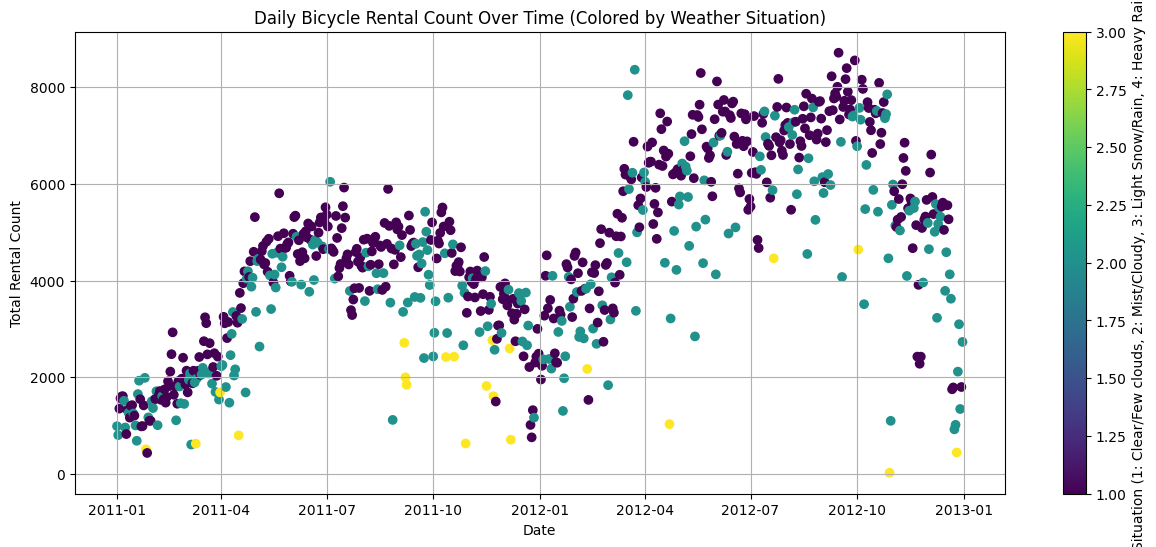

In [3]:
# Visualize the relationship between date and rental count, colored by weather situation
print("\n## 2.1 Rental Count Over Time with Weather Conditions")
plt.figure(figsize=[15, 6])
plt.scatter(df['date'], df['cnt'], c=df['weathersit'], cmap='viridis') # Using a colormap for better distinction
plt.xlabel("Date")
plt.ylabel("Total Rental Count")
plt.title("Daily Bicycle Rental Count Over Time (Colored by Weather Situation)")
plt.colorbar(label='Weather Situation (1: Clear/Few clouds, 2: Mist/Cloudy, 3: Light Snow/Rain, 4: Heavy Rain/Snow/Fog)')
plt.grid(True)
plt.savefig('fig.png')
plt.show()


## 2.2 Average Rental Count by Weather Situation
weathersit
1    4876.786177
2    4035.862348
3    1803.285714
Name: cnt, dtype: float64


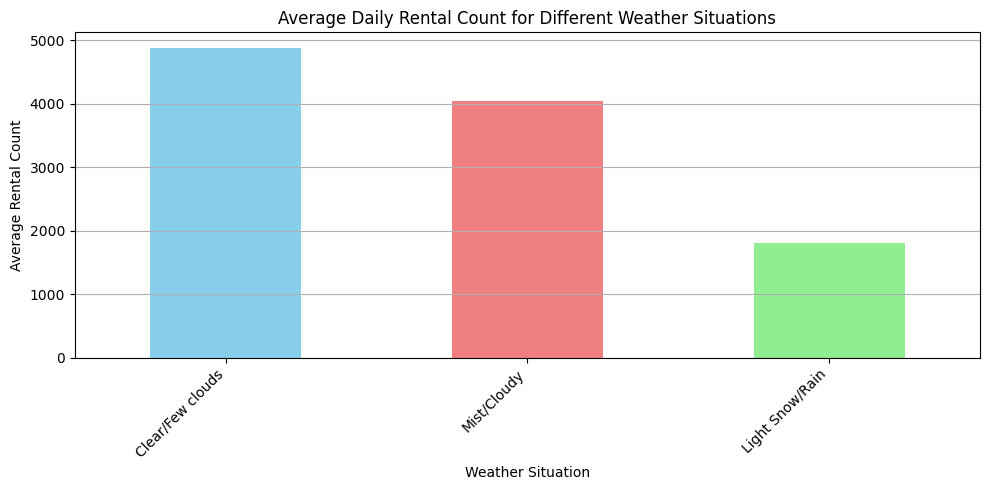

In [4]:
# Analyze the average rental count for each weather situation
print("\n## 2.2 Average Rental Count by Weather Situation")
average_rentals_weather = df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False)
print(average_rentals_weather)
average_rentals_weather.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel("Weather Situation")
plt.ylabel("Average Rental Count")
plt.title("Average Daily Rental Count for Different Weather Situations")
plt.xticks(ticks=[0, 1, 2], labels=['Clear/Few clouds', 'Mist/Cloudy', 'Light Snow/Rain'], rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('fig_3.png')
plt.show()


## 2.3 Rental Count vs. Apparent Temperature


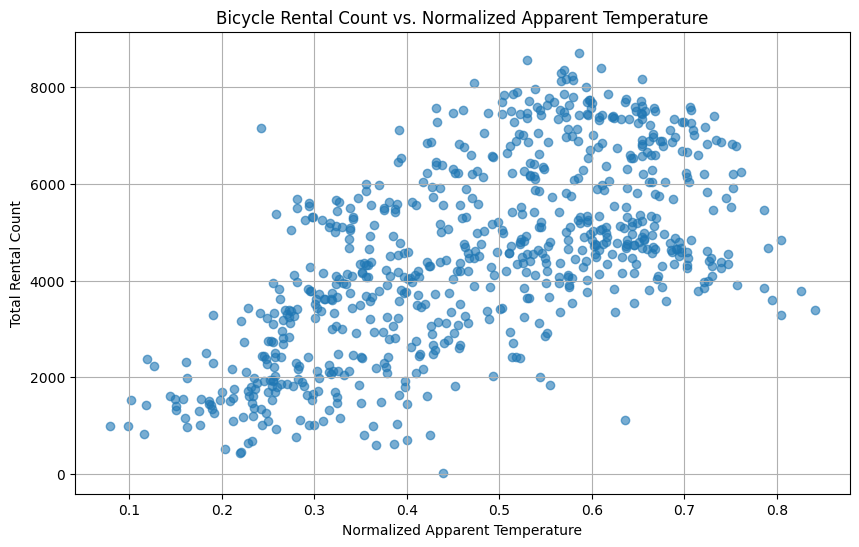

In [5]:
# Visualize the relationship between apparent temperature and rental count
print("\n## 2.3 Rental Count vs. Apparent Temperature")
plt.figure(figsize=[10, 6])
plt.scatter(df['atemp'], df['cnt'], alpha=0.6)
plt.xlabel("Normalized Apparent Temperature")
plt.ylabel("Total Rental Count")
plt.title("Bicycle Rental Count vs. Normalized Apparent Temperature")
plt.grid(True)
plt.savefig('fig_4.png')
plt.show()

In [6]:
# Calculate and display the correlation between 'cnt' and 'atemp'
print("\n## 2.4 Correlation Analysis")
correlation_atemp_cnt = df[['cnt', 'atemp']].corr()
print("Correlation between Total Rental Count and Normalized Apparent Temperature:\n", correlation_atemp_cnt)

# Calculate and display the correlation between 'cnt' and 'temp'
correlation_temp_cnt = df[['cnt', 'temp']].corr()
print("\nCorrelation between Total Rental Count and Normalized Temperature:\n", correlation_temp_cnt)

# Calculate and display the correlation matrix for relevant features
correlation_matrix = df[['cnt', 'atemp', 'temp', 'hum', 'windspeed', 'weathersit']].corr()
print("\nCorrelation Matrix of Relevant Features:\n", correlation_matrix)


## 2.4 Correlation Analysis
Correlation between Total Rental Count and Normalized Apparent Temperature:
             cnt     atemp
cnt    1.000000  0.631066
atemp  0.631066  1.000000

Correlation between Total Rental Count and Normalized Temperature:
            cnt      temp
cnt   1.000000  0.627494
temp  0.627494  1.000000

Correlation Matrix of Relevant Features:
                  cnt     atemp      temp       hum  windspeed  weathersit
cnt         1.000000  0.631066  0.627494 -0.100659  -0.234545   -0.297391
atemp       0.631066  1.000000  0.991702  0.139988  -0.183643   -0.121583
temp        0.627494  0.991702  1.000000  0.126963  -0.157944   -0.120602
hum        -0.100659  0.139988  0.126963  1.000000  -0.248489    0.591045
windspeed  -0.234545 -0.183643 -0.157944 -0.248489   1.000000    0.039511
weathersit -0.297391 -0.121583 -0.120602  0.591045   0.039511    1.000000


## 3. Simple Linear Regression Model (Single Feature)

We will start by building a simple linear regression model using only the 'atemp' (normalized apparent temperature) feature to predict the 'cnt' (total rental count).

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
# Initialize the linear regression model
lr_single = LinearRegression()

# Fit the model using 'atemp' as the independent variable and 'cnt' as the dependent variable
lr_single.fit(df['atemp'].values.reshape(-1, 1), df['cnt'].values.reshape(-1, 1))

LinearRegression()


## 3. Simple Linear Regression Model


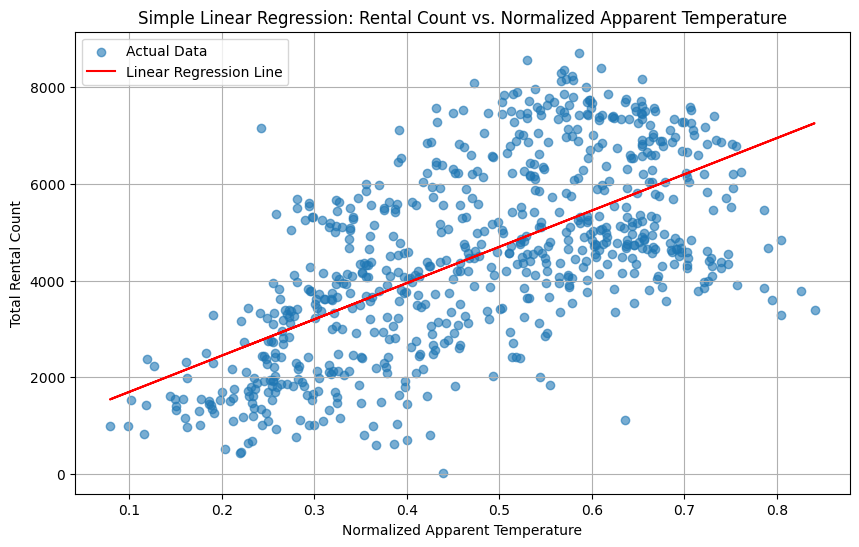

In [9]:
# Visualize the fitted regression line
print("\n## 3. Simple Linear Regression Model")
plt.figure(figsize=[10, 6])
plt.scatter(df['atemp'], df['cnt'], alpha=0.6, label='Actual Data')
plt.plot(df['atemp'], lr_single.predict(df['atemp'].values.reshape(-1, 1)), color='red', label='Linear Regression Line')
plt.xlabel("Normalized Apparent Temperature")
plt.ylabel("Total Rental Count")
plt.title("Simple Linear Regression: Rental Count vs. Normalized Apparent Temperature")
plt.legend()
plt.grid(True)
plt.savefig('fig_5.png')
plt.show()

## 4. Multilinear Regression Model (Initial Features)

Now, we will build a multilinear regression model using multiple features to predict the rental count. We will split the data into training and validation sets to evaluate the model's performance on unseen data.


## 4.1 Multilinear Regression Model Performance (Initial Features) - Validation Set


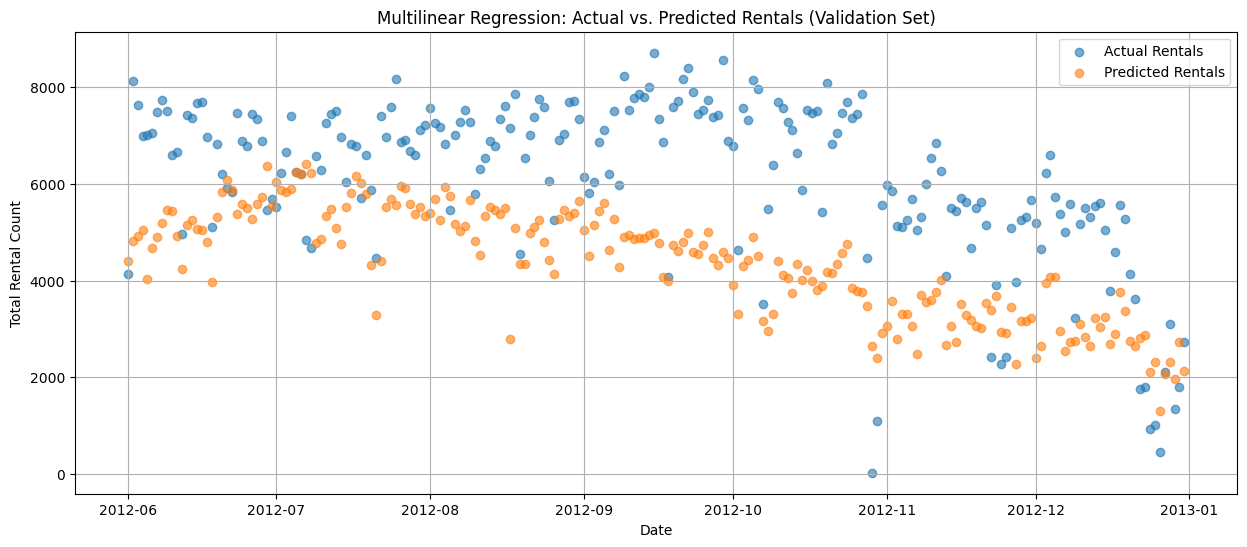


## 4.2 Multilinear Regression Model Performance (Initial Features) - Training Set


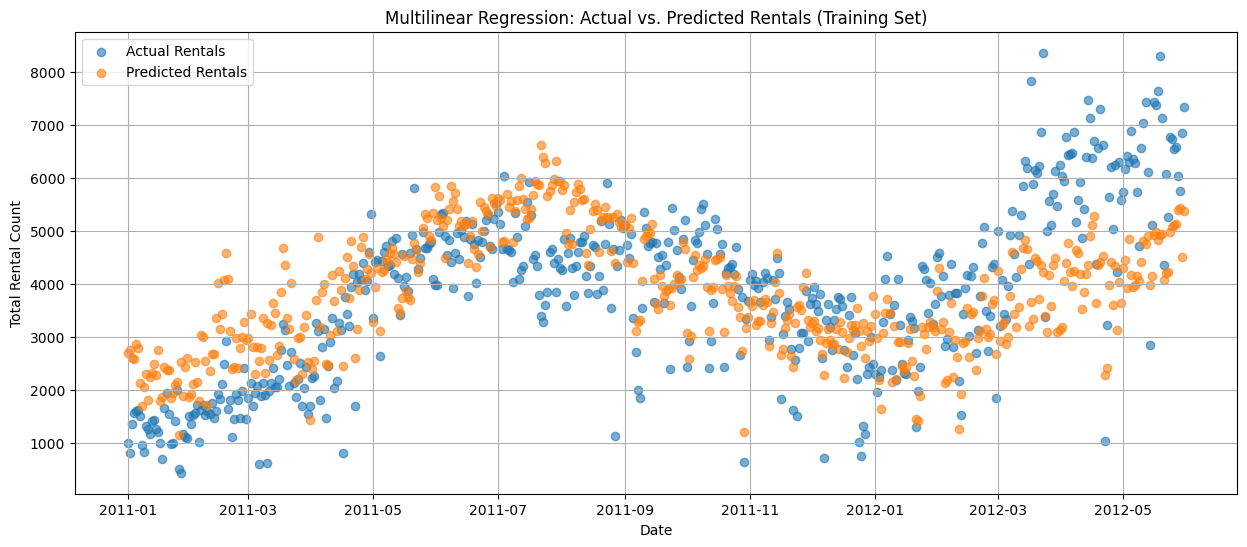


Root Mean Squared Error (RMSE) on Validation Set (Initial Features): 2186.29
This RMSE of 2186.29 indicates that, on average, the model's predictions deviate from the actual daily rental counts by about 2186.29 bicycles.


In [10]:
# Split the data into training and validation sets based on the date
training_set = df[df['date'] < '2012-06-01']
validation_set = df[df['date'] >= '2012-06-01']

# Define the input features and output variable for the training set
training_inputs = training_set[['atemp', 'workingday', 'hum', 'weathersit']].values
training_outputs = training_set[['cnt']].values

# Define the input features and output variable for the validation set
validation_inputs = validation_set[['atemp', 'workingday', 'hum', 'weathersit']].values
validation_outputs = validation_set[['cnt']].values

# Initialize and train the multilinear regression model
lr_multi = LinearRegression()
lr_multi.fit(training_inputs, training_outputs)

# Visualize the model's predictions on the validation set over time
print("\n## 4.1 Multilinear Regression Model Performance (Initial Features) - Validation Set")
plt.figure(figsize=[15, 6])
plt.scatter(validation_set['date'], validation_set['cnt'], label='Actual Rentals', alpha=0.6)
plt.scatter(validation_set['date'], lr_multi.predict(validation_inputs), label='Predicted Rentals', alpha=0.6)
plt.xlabel("Date")
plt.ylabel("Total Rental Count")
plt.title("Multilinear Regression: Actual vs. Predicted Rentals (Validation Set)")
plt.legend()
plt.grid(True)
plt.savefig('fig_6.png')
plt.show()

# Visualize the model's predictions on the training set over time
print("\n## 4.2 Multilinear Regression Model Performance (Initial Features) - Training Set")
plt.figure(figsize=[15, 6])
plt.scatter(training_set['date'], training_set['cnt'], label='Actual Rentals', alpha=0.6)
plt.scatter(training_set['date'], lr_multi.predict(training_inputs), label='Predicted Rentals', alpha=0.6)
plt.xlabel("Date")
plt.ylabel("Total Rental Count")
plt.title("Multilinear Regression: Actual vs. Predicted Rentals (Training Set)")
plt.legend()
plt.grid(True)
plt.savefig('fig_7.png')
plt.show()

# Evaluate the model using Root Mean Squared Error (RMSE) on the validation set
rmse_initial = np.sqrt(((lr_multi.predict(validation_inputs) - validation_outputs)**2).mean())
print(f"\nRoot Mean Squared Error (RMSE) on Validation Set (Initial Features): {rmse_initial:.2f}")
print(f"This RMSE of {rmse_initial:.2f} indicates that, on average, the model's predictions deviate from the actual daily rental counts by about {rmse_initial:.2f} bicycles.")

## 5. Multilinear Regression Model (Adding Windspeed)

Let's see if adding the 'windspeed' feature improves the model's performance.


## 5.1 Multilinear Regression Model Performance (Including Windspeed) - Validation Set


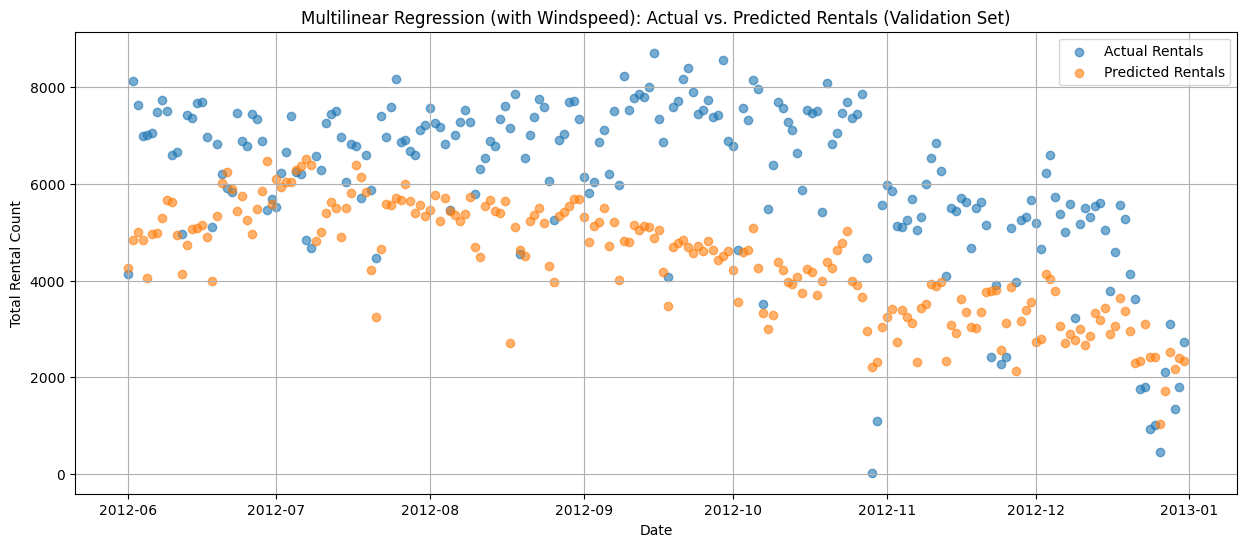


## 5.2 Multilinear Regression Model Performance (Including Windspeed) - Training Set


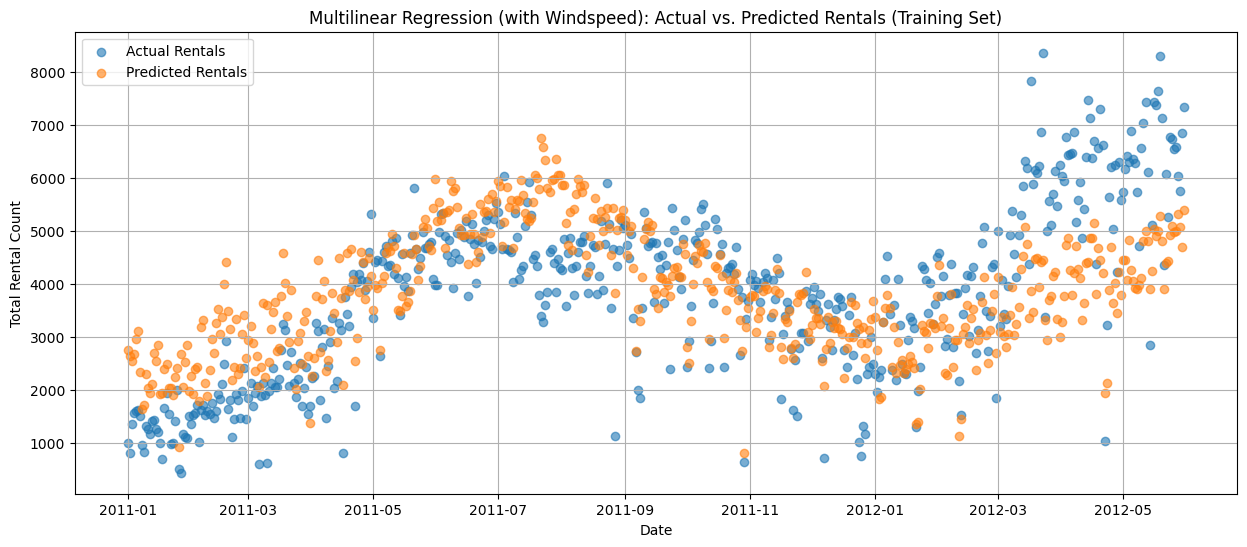


Root Mean Squared Error (RMSE) on Validation Set (Including Windspeed): 2139.20
Adding 'windspeed' resulted in a slight decrease in the RMSE to 2139.20, suggesting a minor improvement in the model's predictive power.


In [11]:
# Define input features including 'windspeed' for training and validation sets
training_inputs_windspeed = training_set[['atemp', 'workingday', 'hum', 'weathersit', 'windspeed']].values
validation_inputs_windspeed = validation_set[['atemp', 'workingday', 'hum', 'weathersit', 'windspeed']].values

# Initialize and train the multilinear regression model with 'windspeed'
lr_multi_windspeed = LinearRegression()
lr_multi_windspeed.fit(training_inputs_windspeed, training_outputs)

# Visualize the model's predictions on the validation set over time
print("\n## 5.1 Multilinear Regression Model Performance (Including Windspeed) - Validation Set")
plt.figure(figsize=[15, 6])
plt.scatter(validation_set['date'], validation_set['cnt'], label='Actual Rentals', alpha=0.6)
plt.scatter(validation_set['date'], lr_multi_windspeed.predict(validation_inputs_windspeed), label='Predicted Rentals', alpha=0.6)
plt.xlabel("Date")
plt.ylabel("Total Rental Count")
plt.title("Multilinear Regression (with Windspeed): Actual vs. Predicted Rentals (Validation Set)")
plt.legend()
plt.grid(True)
plt.savefig('fig_8.png')
plt.show()

# Visualize the model's predictions on the training set over time
print("\n## 5.2 Multilinear Regression Model Performance (Including Windspeed) - Training Set")
plt.figure(figsize=[15, 6])
plt.scatter(training_set['date'], training_set['cnt'], label='Actual Rentals', alpha=0.6)
plt.scatter(training_set['date'], lr_multi_windspeed.predict(training_inputs_windspeed), label='Predicted Rentals', alpha=0.6)
plt.xlabel("Date")
plt.ylabel("Total Rental Count")
plt.title("Multilinear Regression (with Windspeed): Actual vs. Predicted Rentals (Training Set)")
plt.legend()
plt.grid(True)
plt.savefig('fig_9.png')
plt.show()

# Evaluate the model with 'windspeed' using RMSE on the validation set
rmse_windspeed = np.sqrt(((lr_multi_windspeed.predict(validation_inputs_windspeed) - validation_outputs)**2).mean())
print(f"\nRoot Mean Squared Error (RMSE) on Validation Set (Including Windspeed): {rmse_windspeed:.2f}")
print(f"Adding 'windspeed' resulted in a slight decrease in the RMSE to {rmse_windspeed:.2f}, suggesting a minor improvement in the model's predictive power.")

## 6. Feature Engineering: Adding Last Week's Average Rental Count

Based on the previous results and the temporal patterns observed in the data, we will engineer a new feature: the average rental count from the previous week. This could help capture the trend and seasonality in bicycle demand.

In [12]:
# Calculate the average rental count for the previous 7 days
df['last_week'] = (df['cnt'].rolling(window=7, min_periods=1).mean().shift(1))

# Remove rows with NaN values introduced by the rolling window
df = df.dropna()

# Display the DataFrame with the new feature
print("\n## 6. Feature Engineering: Adding 'last_week' feature")
print(df.head(10))


## 6. Feature Engineering: Adding 'last_week' feature
    instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
1         2  2011-01-02       1   0     1        0        0           0   
2         3  2011-01-03       1   0     1        0        1           1   
3         4  2011-01-04       1   0     1        0        2           1   
4         5  2011-01-05       1   0     1        0        3           1   
5         6  2011-01-06       1   0     1        0        4           1   
6         7  2011-01-07       1   0     1        0        5           1   
7         8  2011-01-08       1   0     1        0        6           0   
8         9  2011-01-09       1   0     1        0        0           0   
9        10  2011-01-10       1   0     1        0        1           1   
10       11  2011-01-11       1   0     1        0        2           1   

    weathersit      temp     atemp       hum  windspeed  casual  registered  \
1            2  0.363478  0.353739  0.69


## 6.1 Multilinear Regression Model Performance (Engineered Feature) - Training Set


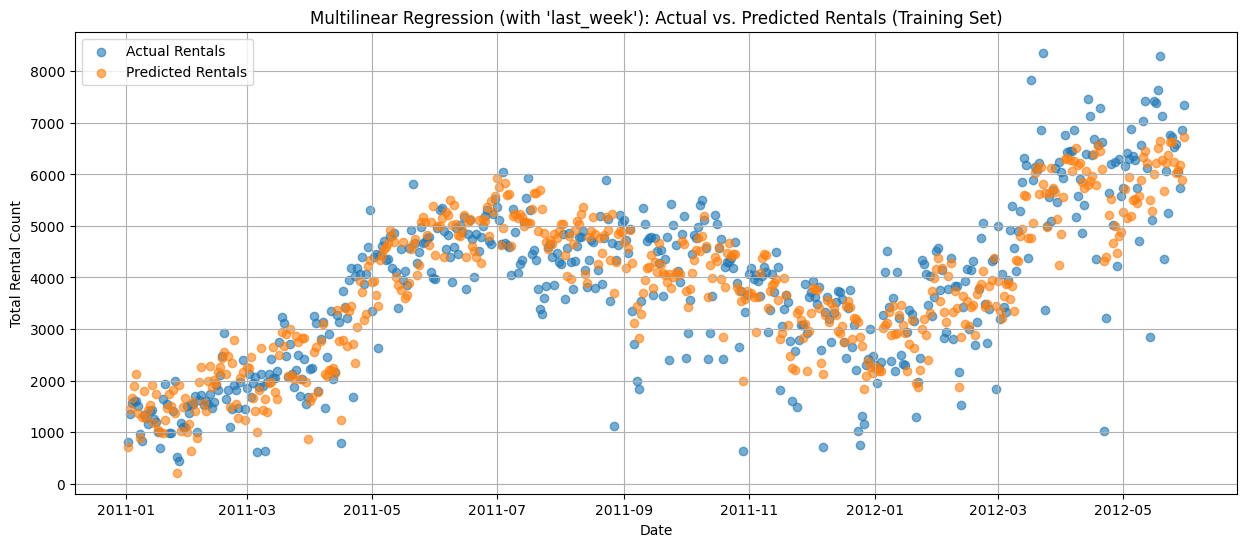


## 6.2 Multilinear Regression Model Performance (Engineered Feature) - Validation Set


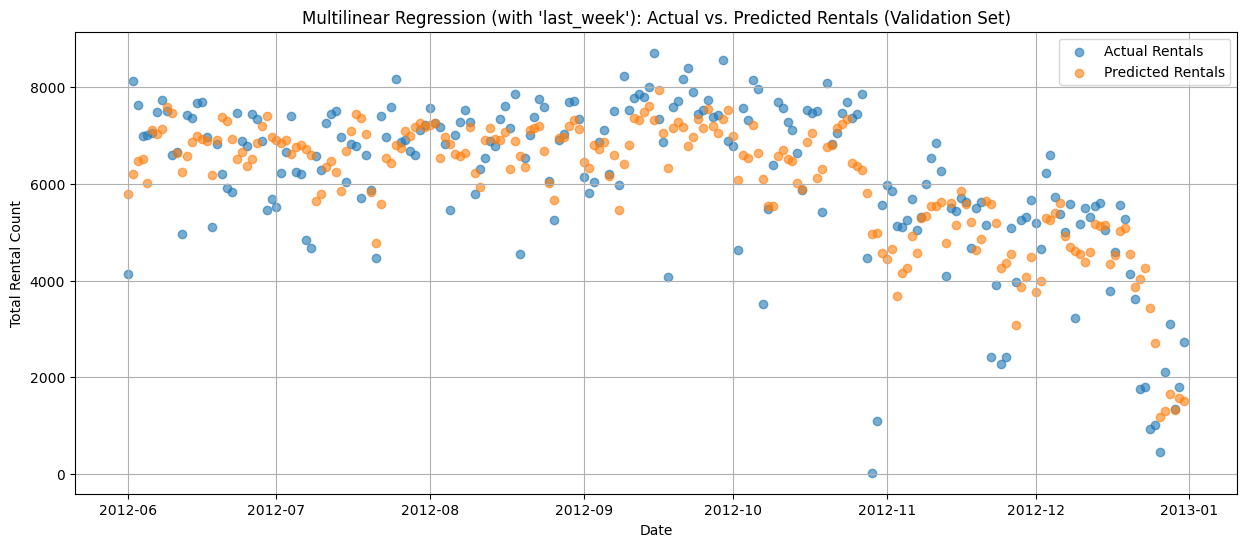


Root Mean Squared Error (RMSE) on Validation Set (Including 'last_week'): 1047.97
The inclusion of the 'last_week' feature led to a significant reduction in the RMSE to approximately 1047.97, demonstrating a substantial improvement in the model's accuracy.


In [13]:
# Split the data into training and validation sets again
training_set_engineered = df[df['date'] < '2012-06-01']
validation_set_engineered = df[df['date'] >= '2012-06-01']

# Define input features including the engineered feature for training and validation sets
training_inputs_engineered = training_set_engineered[['atemp', 'workingday', 'hum', 'weathersit', 'last_week', 'windspeed']].values
training_outputs_engineered = training_set_engineered[['cnt']].values

validation_inputs_engineered = validation_set_engineered[['atemp', 'workingday', 'hum', 'weathersit', 'last_week', 'windspeed']].values
validation_outputs_engineered = validation_set_engineered[['cnt']].values

# Initialize and train the multilinear regression model with the engineered feature
lr_engineered = LinearRegression()
lr_engineered.fit(training_inputs_engineered, training_outputs_engineered)

# Visualize the model's predictions on the training set over time
print("\n## 6.1 Multilinear Regression Model Performance (Engineered Feature) - Training Set")
plt.figure(figsize=[15, 6])
plt.scatter(training_set_engineered['date'], training_set_engineered['cnt'], label='Actual Rentals', alpha=0.6)
plt.scatter(training_set_engineered['date'], lr_engineered.predict(training_inputs_engineered), label='Predicted Rentals', alpha=0.6)
plt.xlabel("Date")
plt.ylabel("Total Rental Count")
plt.title("Multilinear Regression (with 'last_week'): Actual vs. Predicted Rentals (Training Set)")
plt.legend()
plt.grid(True)
plt.savefig('fig_10.png')
plt.show()

# Visualize the model's predictions on the validation set over time
print("\n## 6.2 Multilinear Regression Model Performance (Engineered Feature) - Validation Set")
plt.figure(figsize=[15, 6])
plt.scatter(validation_set_engineered['date'], validation_set_engineered['cnt'], label='Actual Rentals', alpha=0.6)
plt.scatter(validation_set_engineered['date'], lr_engineered.predict(validation_inputs_engineered), label='Predicted Rentals', alpha=0.6)
plt.xlabel("Date")
plt.ylabel("Total Rental Count")
plt.title("Multilinear Regression (with 'last_week'): Actual vs. Predicted Rentals (Validation Set)")
plt.legend()
plt.grid(True)
plt.savefig('fig_11.png')
plt.show()

# Evaluate the model with the engineered feature using RMSE on the validation set
rmse_engineered = np.sqrt(((lr_engineered.predict(validation_inputs_engineered) - validation_outputs_engineered)**2).mean())
print(f"\nRoot Mean Squared Error (RMSE) on Validation Set (Including 'last_week'): {rmse_engineered:.2f}")
print(f"The inclusion of the 'last_week' feature led to a significant reduction in the RMSE to approximately {rmse_engineered:.2f}, demonstrating a substantial improvement in the model's accuracy.")

In [14]:
# ... (Conclusion - quantify RMSE reduction) ...
reduction_percent = ((rmse_initial - rmse_engineered) / rmse_initial) * 100
print(f"\nThe feature engineering step reduced the RMSE on the validation set by approximately {reduction_percent:.2f}%.")


The feature engineering step reduced the RMSE on the validation set by approximately 52.07%.


## 7. Conclusion

In this project, we built a linear regression model to predict daily bicycle rental demand. We started with basic features like apparent temperature, working day status, humidity, and weather situation. The initial multilinear regression model showed a certain level of predictive capability, but the error on the validation set was significant.

By engineering a new feature, 'last_week's average rental count', we were able to incorporate the temporal dependency of the rental demand into our model. This feature significantly improved the model's performance, as evidenced by the substantial reduction in the Root Mean Squared Error (RMSE) on the validation dataset.

The final model, incorporating weather-related features and the 'last_week' feature, demonstrates a much better ability to predict future bicycle rental demand. This highlights the importance of feature engineering in improving the accuracy of predictive models. Further improvements could be explored by considering other features available in the dataset, experimenting with different model types, or applying more advanced time-series analysis techniques.
